In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
def damped_oscillator(z):
    p, q = z
    m  = 1.0
    k = 1.0
    gamma = 0.1

    dpdt = -k * q - gamma * p
    dqdt = p / m

    return (dpdt, dqdt)

In [3]:
import torch
import numpy as np

p0 = torch.tensor([-0.0429839], requires_grad=True)
q0 = torch.tensor([0.44432778], requires_grad=True)
T = 200
dt = 0.1

In [5]:
from leapfrog_integrator import leapfrog

trajectories = leapfrog(p0, q0, damped_oscillator, dt, T, is_hamiltonian=False)

100%|██████████| 200/200 [00:00<00:00, 6881.72it/s]


In [6]:
trajectories.shape

torch.Size([200, 2])

In [7]:
traj = trajectories.detach()

p = traj[:, 0]
q = traj[:, 1]

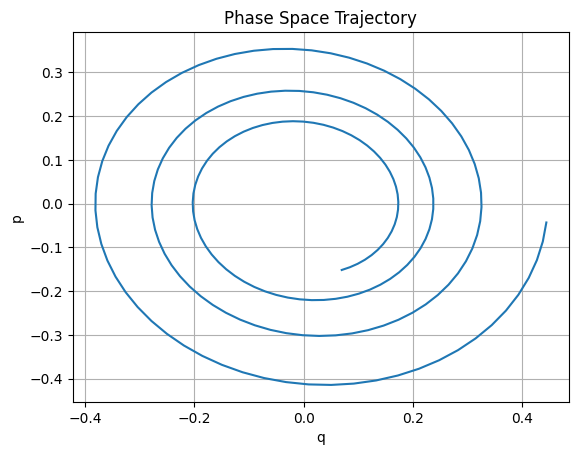

In [8]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(q, p)
plt.xlabel("q")
plt.ylabel("p")
plt.title("Phase Space Trajectory")
plt.grid(True)
plt.show()

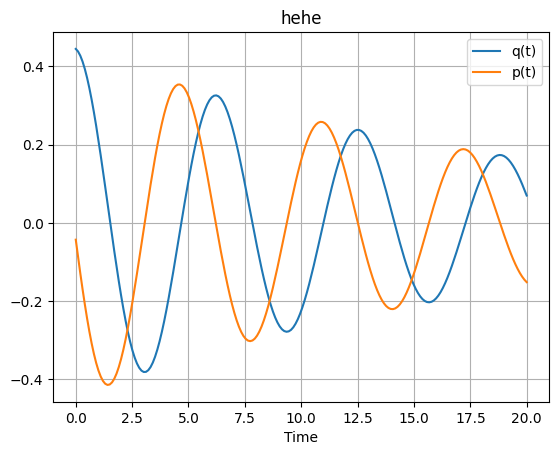

In [9]:
t_eval = np.linspace(0.0, T * dt, T)

plt.figure()
plt.plot(t_eval, q, label="q(t)")
plt.plot(t_eval, p, label="p(t)")
plt.xlabel("Time")
plt.legend()
plt.title("hehe")
plt.grid(True)
plt.show()